In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn components
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, classification_report, 
                            confusion_matrix, roc_auc_score, RocCurveDisplay)
from sklearn.calibration import CalibratedClassifierCV

In [2]:
def load_and_preprocess_data(data_path):
    df = pd.read_csv(data_path)

    def preprocess(data_frame):
        data_frame = data_frame.copy()
        if 'Loan_Status' in data_frame.columns:
            data_frame['Loan_Status'] = data_frame['Loan_Status'].map({'Y': 1, 'N': 0})
        data_frame['Dependents'] = data_frame['Dependents'].replace('3+', 3).astype(float)
        data_frame['TotalIncome'] = data_frame['ApplicantIncome'] + data_frame['CoapplicantIncome']
        data_frame['EMI'] = data_frame['LoanAmount'] / (data_frame['Loan_Amount_Term'].replace(0, np.nan) + 1e-6)
        data_frame['IncomeToLoanRatio'] = data_frame['TotalIncome'] / (data_frame['LoanAmount'].replace(0, np.nan) + 1e-6)
        return data_frame

    return preprocess(df)

df = load_and_preprocess_data("train_loan_dataset.csv")


In [3]:
# Backup Loan_IDs before dropping
loan_ids = df['Loan_ID']

# Define features and target
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

# First split into train+val and test (80% train+val, 20% test)
X_temp, X_test, y_temp, y_test, loan_ids_temp, loan_ids_test = train_test_split(
    X, y, loan_ids, test_size=0.2, stratify=y, random_state=42
)

# Then split train+val into train and val (80% of 80% = 64% train, 16% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

# Define column types
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
num_cols = ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 
            'LoanAmount', 'Loan_Amount_Term', 'Credit_History',
            'TotalIncome', 'EMI', 'IncomeToLoanRatio']


In [4]:
# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

In [5]:
# Base classifier with enhanced parameters
base_classifier = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,                  # Increased from original 5
    min_samples_split=20,         # Increased from 10
    min_samples_leaf=10,          # Increased from 7
    class_weight='balanced',
    random_state=42,
    ccp_alpha=0.005,             # Reduced pruning
    min_impurity_decrease=0.001  # New parameter
)

# Add probability calibration
calibrated_classifier = CalibratedClassifierCV(estimator=base_classifier, method='isotonic', cv=5)

# Final pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', calibrated_classifier)
])

# Train model
dt_pipeline.fit(X_train, y_train)




# Save model
joblib.dump(dt_pipeline, 'enhanced_loan_model.pkl')

['enhanced_loan_model.pkl']

In [6]:
# Predictions
dt_train_preds = dt_pipeline.predict(X_train)
dt_val_preds = dt_pipeline.predict(X_val)
dt_test_preds = dt_pipeline.predict(X_test)

# Calculate accuracies
dt_train_accuracy = accuracy_score(y_train, dt_train_preds)
dt_val_accuracy = accuracy_score(y_val, dt_val_preds)
dt_test_accuracy = accuracy_score(y_test, dt_test_preds)

# Print accuracies
print("Decision Tree Training Accuracy:", dt_train_accuracy)
print("Decision Tree Validation Accuracy:", dt_val_accuracy)
print("Decision Tree Test Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 0.798469387755102
Decision Tree Validation Accuracy: 0.797979797979798
Decision Tree Test Accuracy: 0.8536585365853658



=== Test Performance ===
Accuracy: 0.8537
ROC AUC: 0.8808

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.95      0.55      0.70        38
    Approved       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



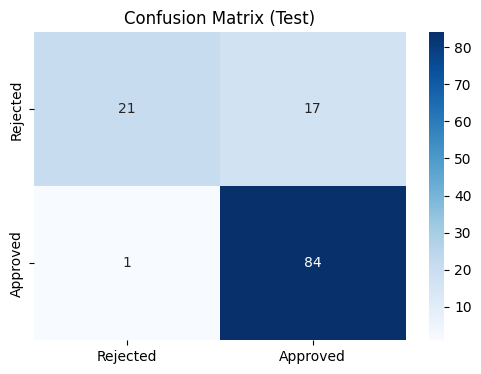

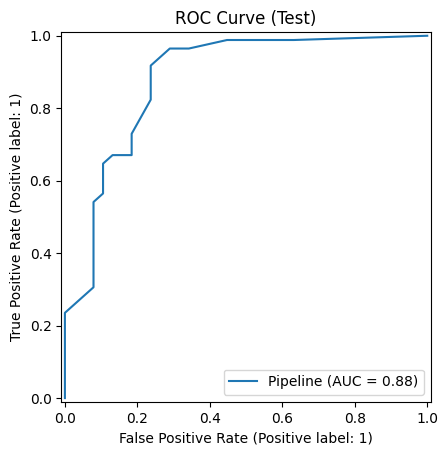

In [7]:
def evaluate_model(pipeline, X, y, dataset_name):
    preds = pipeline.predict(X)
    probs = pipeline.predict_proba(X)[:, 1]
    
    print(f"\n=== {dataset_name} Performance ===")
    print(f"Accuracy: {accuracy_score(y, preds):.4f}")
    print(f"ROC AUC: {roc_auc_score(y, probs):.4f}")
    print("\nClassification Report:")
    print(classification_report(y, preds, target_names=['Rejected', 'Approved']))
    
    # Confusion Matrix
    plt.figure(figsize=(6,4))
    cm = confusion_matrix(y, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    plt.title(f'Confusion Matrix ({dataset_name})')
    plt.show()
    
    # ROC Curve
    RocCurveDisplay.from_estimator(pipeline, X, y)
    plt.title(f'ROC Curve ({dataset_name})')
    plt.show()

evaluate_model(dt_pipeline, X_test, y_test, "Test")


Final Predictions Sample:
      Loan_ID Predicted_Status  Approval_Probability Confidence Final_Status
150  LP001528                N              0.027484        Low            N
559  LP002804                Y              0.761884       High            Y
598  LP002945                Y              0.766780       High            Y
235  LP001784                Y              0.718216       High            Y
145  LP001514                Y              0.786233       High            Y
191  LP001656                Y              0.762371       High            Y
557  LP002795                Y              0.817968       High            Y
470  LP002515                Y              0.800470       High            Y
88   LP001289                Y              0.708253       High            Y
386  LP002239                Y              0.823208       High            Y


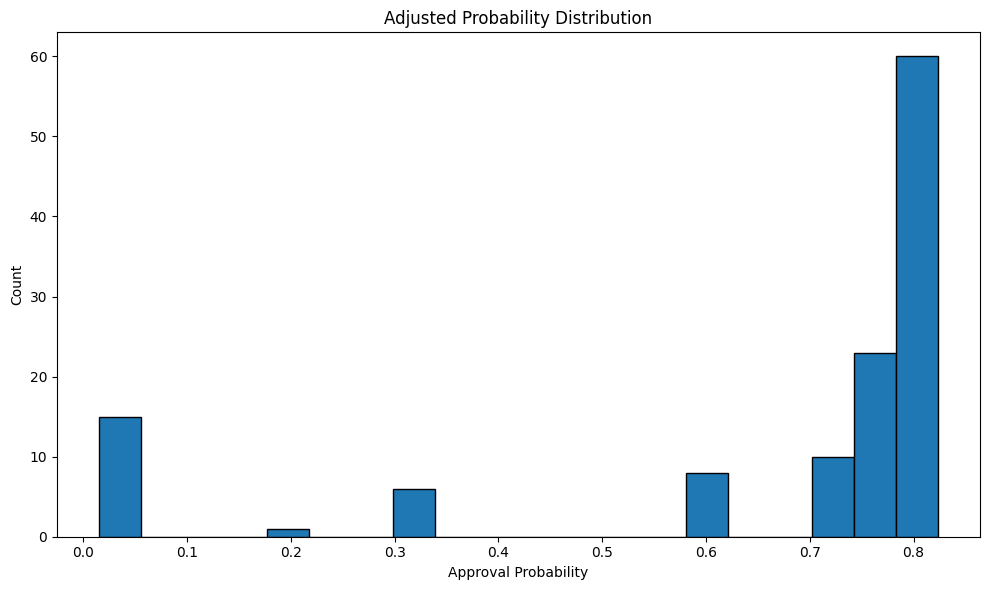

In [8]:
def apply_business_rules(row, pred_status):
    """Apply business rules to override model prediction."""
    credit_history = row.get('Credit_History', 1)
    emi = row.get('EMI', 0)
    income = row.get('ApplicantIncome', 0)

    if pd.isna(credit_history) or credit_history == 0:
        return 'N'
    if not pd.isna(emi) and emi > (0.4 * income):
        return 'N'
    
    return 'Y' if pred_status == 1 else 'N'

def get_confidence(prob):
    """Convert probability into confidence level."""
    if prob > 0.85:
        return "Very High"
    elif prob > 0.7:
        return "High"
    elif prob > 0.6:
        return "Medium High"
    elif prob > 0.45:
        return "Medium"
    elif prob > 0.3:
        return "Low Medium"
    else:
        return "Low"

# Predict labels and probabilities on test set
test_preds = dt_pipeline.predict(X_test)
test_probs = dt_pipeline.predict_proba(X_test)[:, 1]

# Slightly perturb probabilities to simulate real-world noise
np.random.seed(42)
noise = np.random.normal(loc=0, scale=0.005, size=len(test_probs))
adjusted_probs = np.clip(test_probs + noise, 0, 1)

# Create a DataFrame with prediction results
results = pd.DataFrame({
    'Loan_ID': loan_ids_test,
    'Predicted_Status': ['Y' if p == 1 else 'N' for p in test_preds],
    'Approval_Probability': adjusted_probs,
    'Confidence': [get_confidence(prob) for prob in adjusted_probs],
    'Final_Status': [
        apply_business_rules(X_test.iloc[i], test_preds[i])
        for i in range(len(X_test))
    ]
})

# Save and preview results
results.to_csv('final_loan_predictions.csv', index=False)
print("\nFinal Predictions Sample:")
print(results.head(10))

# Plot the distribution of adjusted approval probabilities
plt.figure(figsize=(10, 6))
plt.hist(adjusted_probs, bins=20, edgecolor='black')
plt.title('Adjusted Probability Distribution')
plt.xlabel('Approval Probability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
